## Green's Functions Estimation Using Marchenko Methods - GPU-optimized CuPy code

### Marchenko Method Formulas

The Marchenko method reconstructs the **Green's functions** (both upgoing and downgoing) between a virtual source and surface receivers using single-sided reflection data and an estimate of the direct arrival.

The Marchenko method involves several key equations to estimate Green's functions from seismic reflection data. Here are the formulas corresponding to each section of the code below:

---

### **1. Initial Focusing Functions (Section 4)**

#### a. Downgoing focusing function $f_0^+$ :

$$
f_0^+(\mathbf{x}_f, \mathbf{x}_s, t) = T_d(\mathbf{x}_r, \mathbf{x}_f, -t) \tag{1}
$$

- Where:
  - $T_d$ = Direct arrival wavefield (one-way travel time) from the subsurface focusing point (virtual source) to the surface receivers
  - $T_d(\mathbf{x}_r, \mathbf{x}_f, -t)$ is read as the time-reversed direct arrival at the receiver location $\mathbf{x}_r$ from the virtual source $\mathbf{x}_f$ in the subsurface. Other notations in this note can be read in a similar way.
  - $\mathbf{x}_r$ = Receiver position
  - $\mathbf{x}_f$ = Focal point position
- Implementation: Time reversal of direct arrival (Time-reversed direct arrival)


#### b. Upgoing focusing function $f_0^-$ :

$$
f_0^-(\mathbf{x}_r, \mathbf{x}_f, t) = \Theta(t) \ast \int_S R(\mathbf{x}_r, \mathbf{x}_s, t) \ast f_0^+(\mathbf{x}_f, \mathbf{x}_s, t)  d\mathbf{x}_s   \tag{2}
$$

- Where:
  - $R$ = Reflection response
  - $\Theta$ = Time-window function. It is a muting filter that removes acausal or undesired energy (e.g., above the direct arrival time).
  - $\ast$ = Convolution operator
- Implementation: Convolution of reflection response with $f_0^+$. In frequency domain, this becomes a matrix product.

---

### **2. Iterative Focusing Functions (Section 5)**

For k = 1 to N iterations:
- Downgoing component:
  $$
  m_{k}^{+}(\mathbf{x}_f, \mathbf{x}_s, t) = \Theta(t) \ast \int_S R(\mathbf{x}_r, \mathbf{x}_s, t) \ast f_{k-1}^{-}(\mathbf{x}_r, \mathbf{x}_f, -t) d\mathbf{x}_r
  $$

For the first iteration, for instance,
  $$
  m_{1}^{+}(\mathbf{x}_f, \mathbf{x}_s, t) = \Theta(t) \ast \int_S R(\mathbf{x}_r, \mathbf{x}_s, t) \ast f_{0}^{-}(\mathbf{x}_r, \mathbf{x}_f, -t) d\mathbf{x}_r  \tag{3}
  $$

* Where: $\mathbf{x}_f$: focusing point , $\mathbf{x}_s$: source location (or source side in reflection response), and $\mathbf{x}_r$: receiver location (or receiver side in reflection response)

Implementation: Convolve reflectivity and (time-reversed) fk_minus

---

- Updating upgoing function:
  $$
  f_{k}^{-}(\mathbf{x}_r, \mathbf{x}_f, t) = f_{0}^{-}(\mathbf{x}_r, \mathbf{x}_f, t) + \Theta(t) \ast \int_S R(\mathbf{x}_r, \mathbf{x}_s, t) \ast m_{k}^{+}(\mathbf{x}_f, \mathbf{x}_s, -t) d\mathbf{x}_s
  $$

    $$
    f_k^-(\mathbf{x}_r, \mathbf{x}_f, t) = \Theta(t) \ast \left[f_0^-(\mathbf{x}_r, \mathbf{x}_f, t) + \int R(\mathbf{x}_r, \mathbf{x}_s, t) \ast m_k^+(\mathbf{x}_f, \mathbf{x}_s, -t) \, d\mathbf{x}_s \right]  \tag{4}
    $$
    
- Downgoing function update:
  $$
  f_{k}^{+}(\mathbf{x}_f, \mathbf{x}_s, t) = f_{0}^{+}(\mathbf{x}_f, \mathbf{x}_s, t) + m_{k}^{+}(\mathbf{x}_f, \mathbf{x}_s, t)
  $$

$$
f_k^+( \mathbf{x}_f, \mathbf{x}_s, t) = f_0^+( \mathbf{x}_f, \mathbf{x}_s, t) + \Theta(t) \ast \int_S R( \mathbf{x}_r, \mathbf{x}_s, t) \ast f_{k-1}^-( \mathbf{x}_r, \mathbf{x}_f, -t)  d\mathbf{x}_r
$$

$$
f_k^+( \mathbf{x}_f, \mathbf{x}_s, t) = f_0^+( \mathbf{x}_f, \mathbf{x}_s, t) + \Theta(t) \ast \int_S R( \mathbf{x}_r, \mathbf{x}_s, t) \ast f_{k-1}^-(\mathbf{x}_r, \mathbf{x}_f, -t)  d\mathbf{x}_r \tag{5}
$$

- Where $k$ = Iteration index

---

### **3. Green's Functions (Section 6)**

#### a. Downgoing Green's function ($G^+$):

$$
G^+( \mathbf{x}_r, \mathbf{x}_f, t) = f_k^+( \mathbf{x}_r, \mathbf{x}_f, -t) - \int_S R( \mathbf{x}_r, \mathbf{x}_s, t) \ast f_k^-( \mathbf{x}_s, \mathbf{x}_f, -t)  d\mathbf{x}_s \tag{6}
$$

#### b. Upgoing Green's function ($G^-$):

$$
G^-( \mathbf{x}_r, \mathbf{x}_f, t) = -f_k^-( \mathbf{x}_r, \mathbf{x}_f, t) + \int_S R( \mathbf{x}_r, \mathbf{x}_s, t) \ast f_k^+( \mathbf{x}_s, \mathbf{x}_f, t)  d\mathbf{x}_s  \tag{7}
$$

Note: In numerical implementations, the convolution is often performed in the frequency domain. which is a simple multiplication

#### c. Total Green's function:

$$
G_{\text{total}}(\mathbf{x}_r, \mathbf{x}_s, t) =  G^+(\mathbf{x}_f, \mathbf{x}_s, t)  +  G^-(\mathbf{x}_r, \mathbf{x}_f, t) \tag{8}
$$

$$
G_{\text{total}} = G^{-} + G^{+}
$$

The upgoing Green's Function can also be extracted by:

$$
G^-(t) = G(t) - G^+(t)
$$

Where:

* $G(t)$: Total Green’s function
* $G^+(t)$: Previously computed downgoing part

This is derived from the assumption that the total Green's function is a sum of its downgoing and upgoing parts.

---

### **4. Key Processing Steps**
For whatever reason, you may choose to design your own taper function using the function below (or a modified function of it) instead of the built-in `tukey` in the SciPy library.

1. **Tapering Window (Tukey)**:

    $$
   w_{\text{tukey}}(i) = \begin{cases}
   \frac{1}{2} \left[1 + \cos\left(\pi \frac{2i}{\alpha(N-1)} - 1\right)\right] & 0 \leq i \leq \frac{\alpha(N-1)}{2} \\
   1 & \frac{\alpha(N-1)}{2} < i < (N-1) - \frac{\alpha(N-1)}{2} \\
   \frac{1}{2} \left[1 + \cos\left(\pi \frac{2i}{\alpha(N-1)} - \frac{2}{\alpha} + 1\right)\right] & (N-1) - \frac{\alpha(N-1)}{2} \leq i \leq (N-1)
   \end{cases}  \tag{9}
   $$

   more compact

   $$
   w_{\text{tukey}}(i) = \begin{cases}
   \frac{1}{2} \left[1 + \cos\left(\pi \frac{2i}{\alpha(N-1)} - 1\right)\right] & 0 \leq i \leq \frac{\alpha(N-1)}{2} \\
   1 & \frac{\alpha(N-1)}{2} < i < (N-1)(1-\frac{\alpha}{2}) \\
   \frac{1}{2} \left[1 + \cos\left(\pi \frac{2i}{\alpha(N-1)} - \frac{2}{\alpha} + 1\right)\right] & (N-1)(1-\frac{\alpha}{2}) \leq i \leq (N-1)
   \end{cases}  \tag{10}
   $$
       
<!--     $$
    w_{\alpha}(n) =
    \begin{cases}
    \frac{1}{2} \left[1 + \cos\left(\pi \left(\frac{2n}{\alpha(N-1)} - 1\right)\right)\right] & 0 \leq n \leq \frac{\alpha(N-1)}{2} \\
    1 & \frac{\alpha(N-1)}{2} < n < (N-1) - \frac{\alpha(N-1)}{2} \\
    \frac{1}{2} \left[1 + \cos\left(\pi \left(\frac{2n}{\alpha(N-1)} - \frac{2}{\alpha} + 1\right)\right)\right] & (N-1) - \frac{\alpha(N-1)}{2} \leq n \leq N-1
    \end{cases}
    $$ -->

   - Where $\alpha$ = taper fraction (`tp`)
      
#### Comparison with Other Windows
| Window Type | Best For | Spectral Leakage |
|-------------|----------|------------------|
| Tukey       | General purpose with controllable tapering | Moderate |
| Hann        | General purpose | Good |
| Hamming     | Narrowband analysis | Fair |
| Rectangular | Transient detection | Poor |

The Tukey window provides a good compromise between frequency resolution and spectral leakage control, especially when you need to adjust the amount of tapering for your specific application. The Tukey function above is controlled by the `alpha` parameter. The `alpha` parameter controls the transition:
- `alpha=0`: Equivalent to a rectangular window (no tapering)
- `alpha=1`: Equivalent to a Hann window (full cosine taper)
       
2. **Pre-direct Arrival Mute**:

   $$
    G_{\text{final}} = G_{\text{total}} \cdot (1 - \Theta(t))
   $$
   - Removes artifacts before first arrival

---

### **5. Normalization**
$$
G_{\text{norm}} = \frac{G}{\max(|G_{\text{total}}|)}
$$

$$
G_{\text{norm}} = \frac{G}{\max_{t,\mathbf{x}_r}( |G_{\text{total}}|)}
$$

- Ensures consistent amplitude scaling
  
---

### **6. Reference True Green's Function (`true`)**

This is typically computed via direct **forward modeling** (e.g., finite difference, finite element, or Kirchhoff modeling) using the known subsurface model $c(x, z)$ (velocity field):

$$
\left( \frac{1}{c^2(x, z)} \frac{\partial^2}{\partial t^2} - \nabla^2 \right) G(x, z, t) = \delta(x - x_s)\delta(z - z_s)\delta(t)  \tag{11}
$$

Where:

* $c(x, z)$: Velocity model
* $\delta$: Dirac delta function at the source location $(x_s, z_s)$

This equation ensures that `true` serves as the ground truth against which the retrieved Green’s functions are compared.

---

### **Variable Correspondence Table**

| Math Symbol | Code Variable | Description |
|------------|---------------|-------------|
| $R$        | `sg`          | Reflection response |
| $T_d$      | `direct`      | Direct arrival |
| $\Theta$   | `theta`       | Time window function (causality constraint) |
| $f_k^+$    | `fk_plus`     | Downgoing focusing function |
| $f_k^-$    | `fk_minus`    | Upgoing focusing function |
| $G^+$      | `g_plus`      | Downgoing Green's function |
| $G^-$      | `g_minus`     | Upgoing Green's function |
| $w$        | `tap`         | Taper window |
| $\alpha$   | `tp`          | Taper fraction |
| $N$        | `ns`          | Number of receivers |
| $\mathbf{x}_r$          | `-`     | Receiver position vector |
| $\mathbf{x}_f$        | `-`         | Focal point position vector (focusing point) |
| $\mathbf{x}_s$         | `-`          | Source position vector |
| $S$                   | `-`          | Measurement Surface |
| $\ast$        | `-`         | Convolution Operator |
| $k$         | `itr `          | Iteration index |
| $t$                   | `-`          | time |

These equations implement the Marchenko method to retrieve Green's functions from single-sided reflection measurements, enabling redatuming without detailed velocity model information. The iterative scheme progressively removes artifacts caused by internal multiples.

### **Summary**

* The **direct arrival** $T_d$ gives $f_0^+$.
* Using $f_0^+$ and the **reflection response** $R$, we compute $f_0^-$.
* We iteratively update $f_k^+$ and $f_k^-$ using $R$ and a time-reversed convolution process.
* The final Green's functions $G^-$ and $G^+$ are computed from these focusing functions and $R$, from which **total Green's function** is constructed.

In summary, Marchenko methods allow for the reconstruction of $G(t, \mathbf{x}_r, \mathbf{x}_f)$ using only:
- Surface measurements ($\mathbf{x}_s$ and $\mathbf{x}_r$ at the surface)
- An estimate of the direct arrival
- A time window (causality constraint)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### GPU-optimized CuPy code

The code cell below successfully executes and computes the **Marchenko Green's functions** and **focusing functions** from the **input reflectivity**, **direct arrival**, **filter (theta)**, and **ground-truth Green’s functions** (for comparison).

---

### Key Outputs

1. **`g_total`** – The full Green's function retrieved via Marchenko method, including both upgoing and downgoing wavefields.
2. **`g_plus` / `g_minus`** – Separated downgoing and upgoing parts of the Green's function.
3. **`fk_plus` / `fk_minus`** – Final focusing functions after iterative Marchenko updates.
4. **`f0_plus` / `f0_minus`** – Initial estimates of the focusing functions using only the direct arrival.
5. **`true`** – Ground-truth solution (presumably from modeling or full wavefield data), for comparison.


Loading data and transferring to GPU...
Initializing focusing functions on GPU...
Starting GPU iterative calculation (5 iterations)...
Calculating Green's functions on GPU...
Transferring data back to CPU for plotting...
Saved: /content/Marchenko_Outputs/01_Shot_Gathers.png
Saved: /content/Marchenko_Outputs/02_Focusing_Functions.png
Saved: /content/Marchenko_Outputs/03_Greens_Functions.png


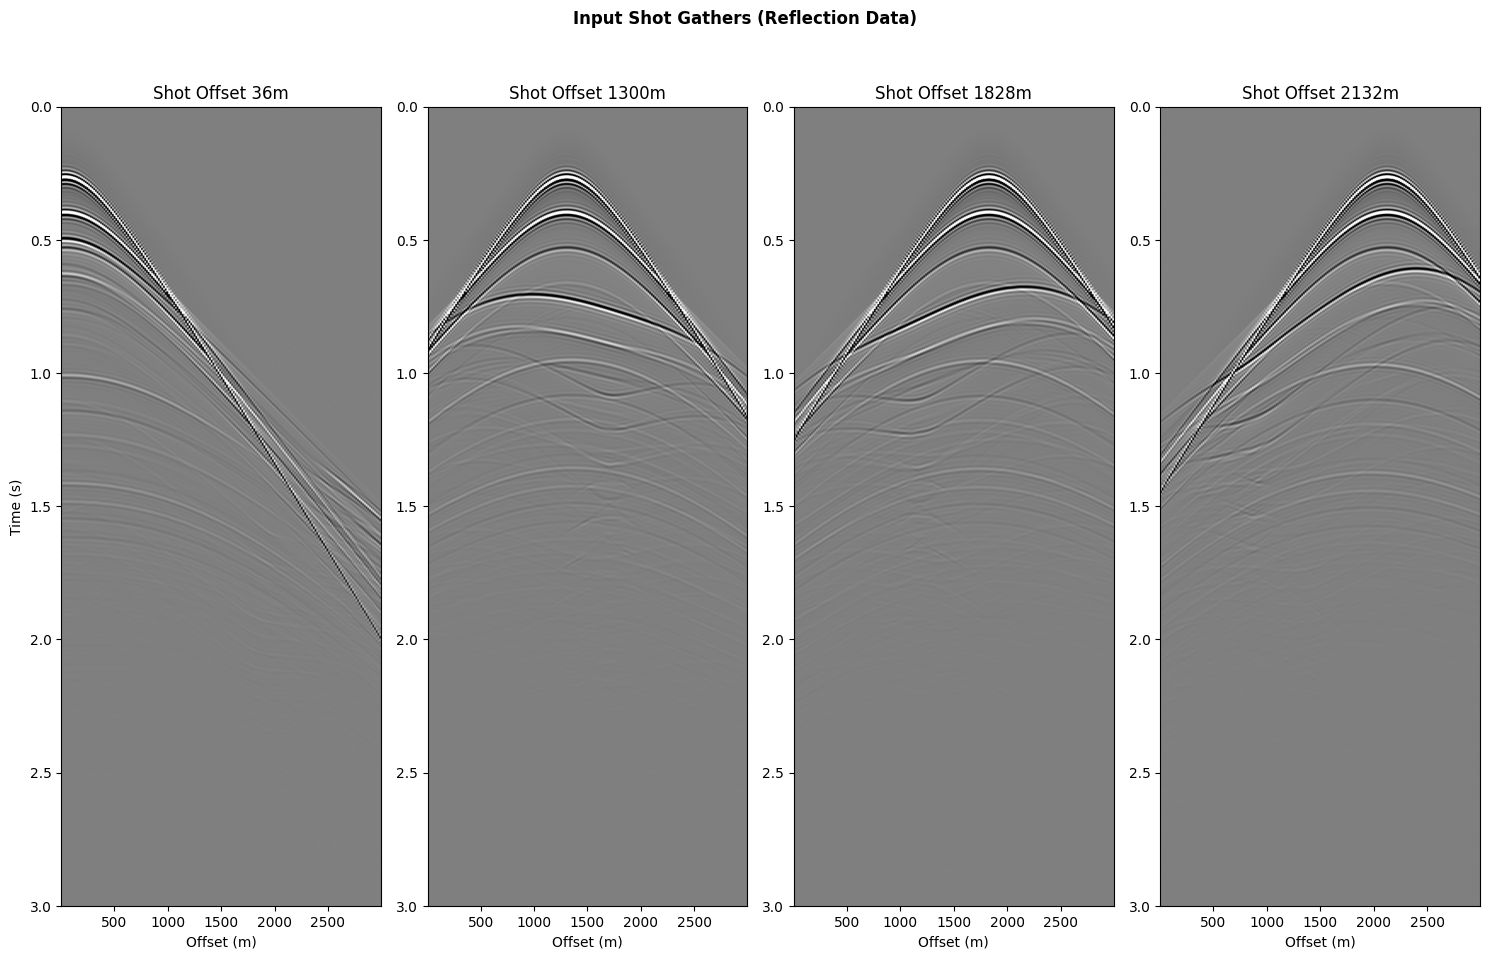

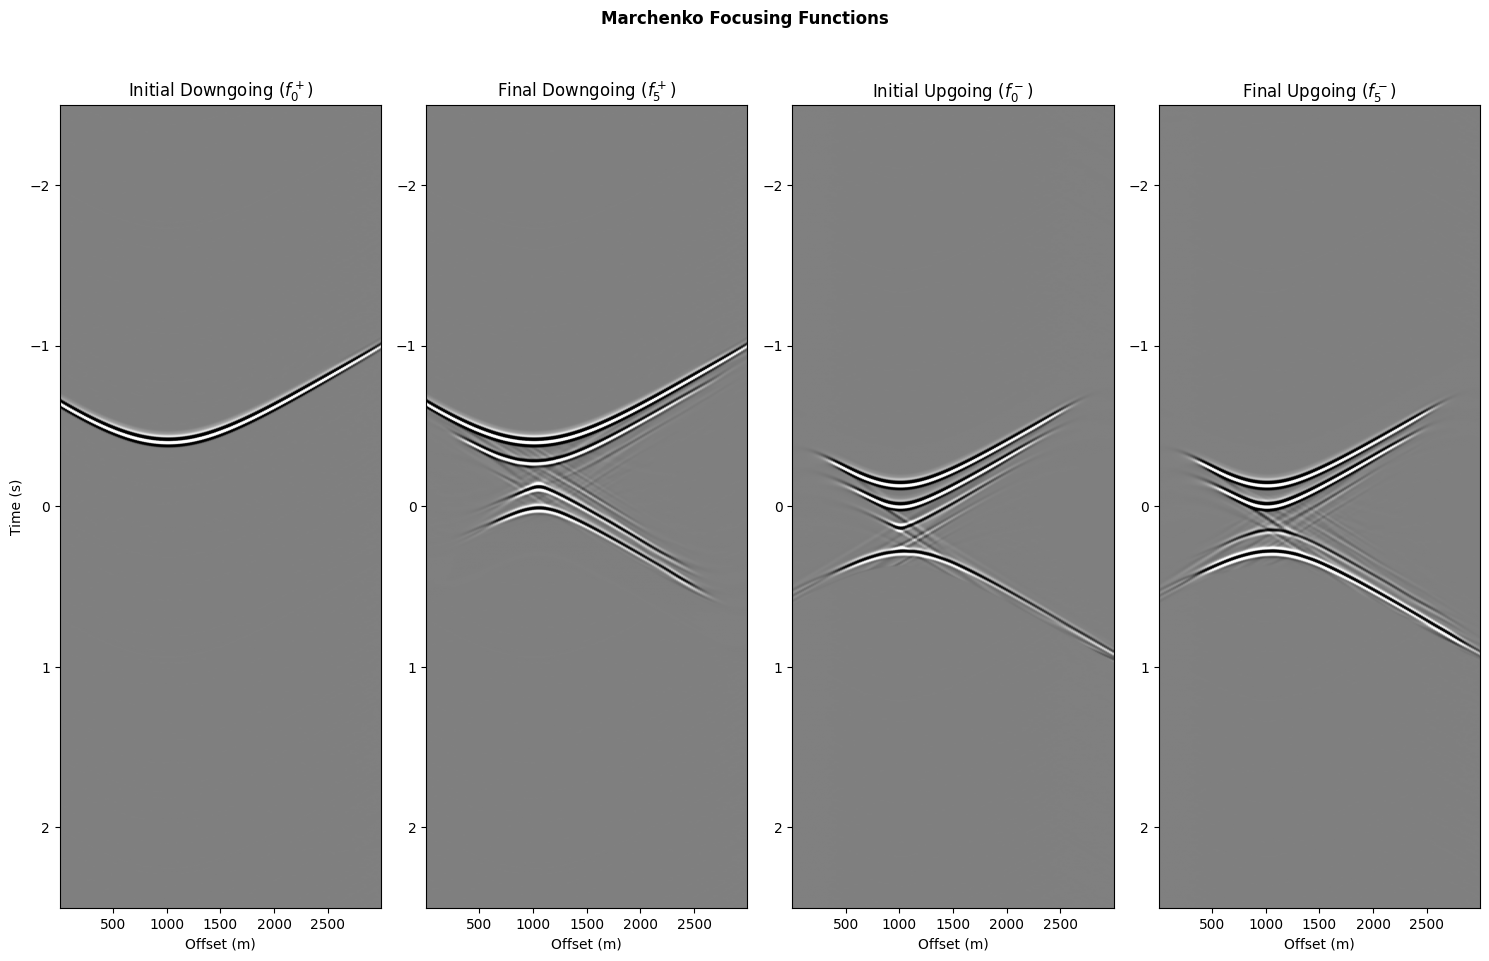

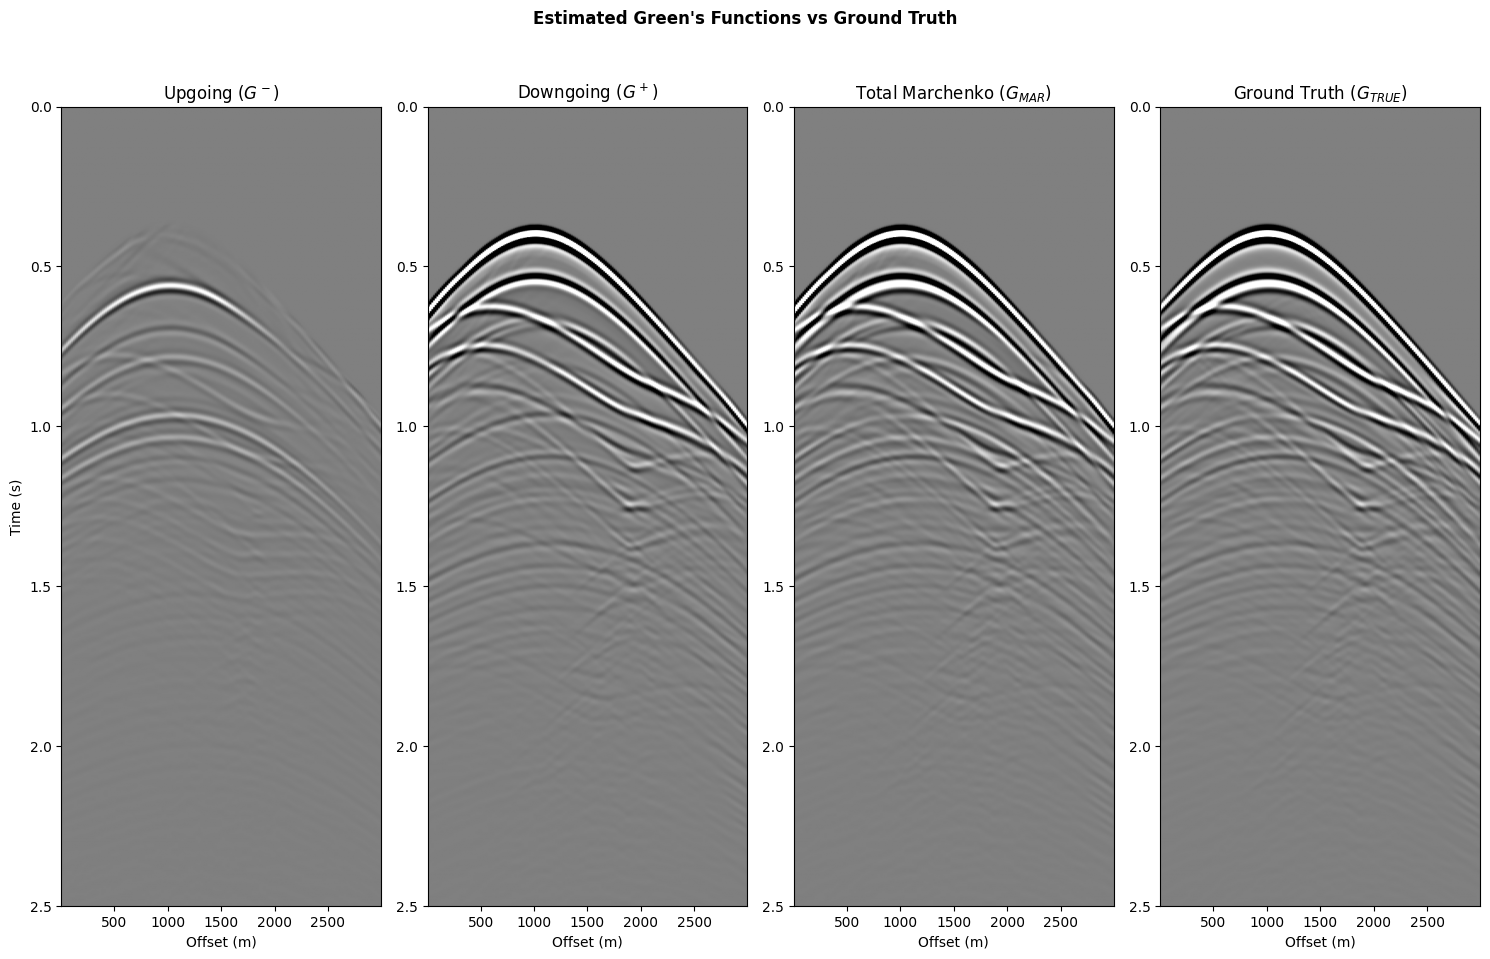

GPU Marchenko processing and plotting complete!


In [2]:
"""
Green's Functions Using Marchenko Methods (GPU Optimized)

This script calculates the upgoing and downgoing Green's functions of a
subsurface target using single-sided surface reflection data. It utilizes
the iterative Marchenko method to remove internal multiples and retrieve
the true wavefield.

Optimized for Google Colab using CuPy.
"""

# If you are not running on COLAB, run !pip install cupy-cuda12x to install CuPy.
# If using COLAB, CuPy is usually pre-installed, but if you encounter errors,
# run this in a cell before this script: !pip install cupy-cuda12x

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat
from scipy.signal.windows import tukey

# The tukey function from scipy.signal.windows generates a Tukey window
# (also known as a tapered cosine window), which is commonly used
# in signal processing to reduce spectral leakage when performing Fourier transforms

def main():
    """
    Main function to execute the Marchenko Green's Function retrieval.

    Workflow:
    1. Load reflection data, direct arrival estimate, and causality filter.
    2. Move data from CPU (Host RAM) to GPU (Device VRAM).
    3. Initialize focusing functions from the time-reversed direct arrival.
    4. Iteratively solve the Marchenko equations to update focusing functions.
    5. Construct the final separated Green's functions.
    6. Transfer results back to CPU for Matplotlib visualization.
    7. Save outputs as discrete PNG files.
    """

    #---------------------------------
    # 1) USER INPUT - SETUP VARIABLES
    #---------------------------------
    nitr    = 5                    # Number of iterations (higher = better multiple removal, longer run time)
    tp      = 0.2                  # Tukey taper fraction (alpha) to smooth edge effects across receivers
    scaling = 1                    # Amplitude scaling factor for the Marchenko equations
    dt      = 0.002                # Time sampling interval in seconds (2 ms)
    dx      = 16                   # Distance between surface receivers in meters
    o_min   = 4                    # Minimum offset (distance of the first receiver) in meters

    # Define the directory where your .mat files live.
    # base_dir = os.path.join(os.getcwd(), 'Marchenko')

    # If using Colab, ensure your Drive is mounted and update this path.
    # If not using Colab, uncomment the base_dir above and comment the one below
    base_dir = '/content/drive/MyDrive/Marchenko'
    mat_dir  = os.path.join(base_dir, 'DATA', 'MAT')

    #-------------------------------------------
    # 2) LOAD DATA TO CPU, THEN TRANSFER TO GPU
    #-------------------------------------------
    print("Loading data and transferring to GPU...")

    try:
        # Load standard NumPy arrays from the .mat files
        data_dict = {
            key: loadmat(os.path.join(mat_dir, fname))[key]
            for key, fname in zip(['sg', 'td', 'theta', 'gt'], [
                'ICCR_marchenko_R.mat',       # sg: Surface Reflection Response (R)
                'ICCR_marchenko_TD.mat',      # td: Direct arrival (T_d)
                'ICCR_marchenko_theta.mat',   # theta: Muting time-window / Causality filter
                'ICCR_marchenko_GT.mat'       # gt: Ground Truth Green's function for final comparison
            ])
        }

        # TRANSFER TO GPU: Convert NumPy arrays to CuPy arrays.
        # We enforce float32/complex64 precision to maximize T4 GPU performance
        # and prevent Out-Of-Memory (OOM) errors.
        sg     = cp.asarray(data_dict['sg'], dtype=cp.float32)
        direct = cp.asarray(data_dict['td'], dtype=cp.float32)
        theta  = cp.asarray(data_dict['theta'], dtype=cp.float32)
        true   = cp.asarray(data_dict['gt'], dtype=cp.float32)

    except Exception as e:
        print(f"Error loading data: {e}\nPlease check your file paths.")
        return

    #------------------------------------
    # 3) AUTOMATICALLY DEFINED VARIABLES
    #------------------------------------
    ns = sg.shape[1]                          # Total number of receiver positions
    ro = cp.arange(o_min, o_min + ns*dx, dx)  # Array of actual receiver offsets
    ts = sg.shape[0]                          # Total number of time samples
    max_t = (ts // 2) * dt                    # Maximum recording time in seconds

    # Scale reflection response and transform to the Frequency Domain.
    # Convolutions in the time domain are simple multiplications in the frequency domain.
    sg_fft = cp.fft.fft(sg * (-2 * dt * dx * scaling), axis=0)

    # Create the source tapering window (Tukey window).
    # Generated on CPU using SciPy, then transferred to GPU via cp.asarray.
    tap_vector = cp.asarray(tukey(ns, alpha=tp), dtype=cp.float32)

    #-------------------------------------------
    # 4) FOCUSING FUNCTIONS - INITIAL ESTIMATES
    #-------------------------------------------
    print("Initializing focusing functions on GPU...")

    # EQUATION: f0_plus(t) = T_d(-t)
    # The initial downgoing focusing function is simply the time-reversed direct arrival.
    # Time reversal in frequency domain = complex conjugate. np.flipud acts as the time-reversal here before FFT.
    f0_plus = cp.fft.fft(cp.flipud(direct), axis=0)

    # Pre-allocate array for the initial upgoing focusing function
    f0_minus = cp.zeros_like(f0_plus)

    # EQUATION: f0_minus(t) = Theta(t) * [R(t) * f0_plus(t)]
    # We convolve the reflection response (sg_fft) with the initial downgoing focusing function.
    for nsrc in range(ns):    # Loop over all source positions and then stack
        # cp.tile duplicates the 1D array to match dimensions for vector multiplication
        rep_f0 = cp.tile(f0_plus[:, nsrc, cp.newaxis], (1, ns))
        # Multiply by the taper vector to smooth boundary effects
        f0_minus += rep_f0 * sg_fft[:, :, nsrc] * tap_vector[nsrc]

    # Transform back to time domain to apply the causality window (Theta)
    f0_minus_time = cp.real(cp.fft.ifft(f0_minus, axis=0))
    # ifftshift centers the zero-time index properly before applying the mute
    f0_minus_time = cp.fft.ifftshift(f0_minus_time, axes=0) * theta

    # Send the windowed function back to the frequency domain for the next steps
    f0_minus = cp.fft.fft(f0_minus_time, axis=0)

    # Pre-calculate the time-reversed version of f0_minus (required for the iterative loop)
    fk_minus_tr = cp.fft.fft(cp.flipud(f0_minus_time), axis=0)

    #-----------------------------------------------
    # 5) FOCUSING FUNCTIONS - ITERATIVE CALCULATION
    #-----------------------------------------------
    print(f"Starting GPU iterative calculation ({nitr} iterations)...")

    for itr in range(nitr):
        # Reset intermediate arrays for the current iteration
        fk_minus = cp.zeros_like(fk_minus_tr)
        mk_plus  = cp.zeros_like(fk_minus_tr)

        # STEP A: Update the downgoing intermediate function (mk_plus)
        # Convolve reflectivity with time-reversed fk_minus (fk_minus_tr)
        # EQUATION: mk_plus = Theta(t) * [ R(t) * f_minus(-t) ]
        for nsrc in range(ns):
            rep_fk = cp.tile(fk_minus_tr[:, nsrc, cp.newaxis], (1, ns))
            # Multiply by taper value for this source
            mk_plus += rep_fk * sg_fft[:, :, nsrc] * tap_vector[nsrc]

        # Apply causality window to mk_plus in time domain
        mk_plus_time = cp.real(cp.fft.ifft(mk_plus, axis=0))

        # The ifftshift function is crucial for correct time-domain alignment after performing an
        # Inverse Fast Fourier Transform (IFFT). It reorders (or shifts) the elements
        # of a vector or matrix so that the zero-frequency component is moved to the beginning of the array.

        mk_plus_time = cp.fft.ifftshift(mk_plus_time, axes=0) * theta
        mk_plus = cp.fft.fft(cp.flipud(mk_plus_time), axis=0)

        # Reset fk_minus before updating for next convolution
        fk_minus = cp.zeros_like(mk_plus)

        # STEP B: Update the upgoing focusing function (fk_minus)
        # Convolve reflectivity with mk_plus (time reversed)
        # EQUATION: fk_minus = Theta(t) * [ R(t) * mk_plus(-t) ]
        for nsrc in range(ns):
            rep_mk = cp.tile(mk_plus[:, nsrc, cp.newaxis], (1, ns))
            # Multiply by taper value for this source
            fk_minus += rep_mk * sg_fft[:, :, nsrc] * tap_vector[nsrc]

        # Combine the initial estimate (f0_minus) with the iterative update (fk_minus)
        fk_minus_time = cp.real(cp.fft.ifft(f0_minus, axis=0))
        fk_minus_conv = cp.fft.ifftshift(cp.real(cp.fft.ifft(fk_minus, axis=0)), axes=0)
        fk_minus_time = fk_minus_time + theta * fk_minus_conv

        # Prepare for the next iteration (transfer back to frequency domain)
        fk_minus_tr = cp.fft.fft(cp.flipud(fk_minus_time), axis=0)
        fk_minus    = cp.fft.fft(fk_minus_time, axis=0)

    # Calculate the total final downgoing focusing function
    # EQUATION: fk_plus = f0_plus + mk_plus
    fk_plus = f0_plus + mk_plus

    #---------------------------------
    # 6) CALCULATE GREEN'S FUNCTIONS
    #---------------------------------
    print("Calculating Green's functions on GPU...")
    g_minus = cp.zeros_like(fk_plus)
    g_plus  = cp.zeros_like(fk_plus)

    # Convolve reflectivity with the newly calculated focusing functions
    for nsrc in range(ns):
        # EQUATION: g_plus component = R(t) * f_minus(-t)
        rep_fk_tr = cp.tile(fk_minus_tr[:, nsrc, cp.newaxis], (1, ns))
        g_plus += rep_fk_tr * sg_fft[:, :, nsrc] * tap_vector[nsrc]

        # EQUATION: g_minus component = R(t) * f_plus(t)
        rep_fk_plus = cp.tile(fk_plus[:, nsrc, cp.newaxis], (1, ns))
        g_minus += rep_fk_plus * sg_fft[:, :, nsrc] * tap_vector[nsrc]

    # Finalize Downgoing Green's Function (G+)
    # Convert to time domain and apply corrections
    g_plus_time = cp.flipud(cp.real(cp.fft.ifft(fk_plus, axis=0)))
    g_plus_conv = cp.fft.ifftshift(cp.real(cp.fft.ifft(g_plus, axis=0)), axes=0)
    g_plus      = g_plus_time - g_plus_conv

    # Finalize Upgoing Green's Function (G-)
    g_minus_time = -cp.real(cp.fft.ifft(fk_minus, axis=0))
    g_minus_conv = cp.fft.ifftshift(cp.real(cp.fft.ifft(g_minus, axis=0)), axes=0)
    g_minus      = g_minus_time + g_minus_conv

    # Total Green's Function is the sum of the upgoing and downgoing parts
    g_total = g_minus + g_plus

    #---------------------------------------------
    # 7) NORMALIZE SIGNAL AMPLITUDE & APPLY MUTES
    #---------------------------------------------
    # Scale everything strictly from -1 to 1 based on maximum amplitude
    max_val  = cp.max(cp.abs(g_total))
    true    /= cp.max(cp.abs(true))
    g_plus  /= max_val
    g_minus /= max_val
    g_total /= max_val

    # Convert focusing functions back to time domain for plotting
    f0_plus_time  = cp.real(cp.fft.ifft(f0_plus, axis=0))
    f0_minus_time = cp.real(cp.fft.ifft(f0_minus, axis=0))
    fk_plus_time  = cp.real(cp.fft.ifft(fk_plus, axis=0))
    fk_minus_time = cp.real(cp.fft.ifft(fk_minus, axis=0))

    # Normalize focusing functions independently
    fk_plus_max   = cp.max(cp.abs(fk_plus_time))
    f0_plus_time  /= fk_plus_max
    f0_minus_time /= fk_plus_max
    fk_minus_time /= fk_plus_max
    fk_plus_time  /= fk_plus_max

    #-------------------------------
    # APPLY PRE-DIRECT ARRIVAL MUTE
    #-------------------------------
    """
    Theoretically this step is not required. However, marchenko methods in higher
    dimensions are more prone to errors, and these errors manifest themselves as noise
    — this filter is removing some of this noise.
    """
    # This acts as a surgical mute to remove high-dimensional scattered noise
    # before the first arrival breaks. filter2 is the exact inverse of our causality window.
    filter2  = 1 - theta
    g_total *= filter2
    g_minus *= filter2
    g_plus  *= filter2
    true    *= filter2

    #-------------------------------------
    # 8) TRANSFER TO CPU AND PLOT RESULTS
    #-------------------------------------
    print("Transferring data back to CPU for plotting...")

    # TRANSFER TO CPU: Matplotlib cannot plot CuPy (GPU) arrays.
    # We must use the .get() method to pull the arrays back into standard NumPy RAM.
    ro_cpu = ro.get()
    time_axis = np.arange(-max_t, max_t + dt, dt)
    time_axis_pos = time_axis[ts//2:]

    # Arrays needed for plotting
    sg_fft_cpu   = sg_fft.get()
    f0_plus_cpu  = f0_plus_time.get()
    fk_plus_cpu  = fk_plus_time.get()
    f0_minus_cpu = f0_minus_time.get()
    fk_minus_cpu = fk_minus_time.get()
    g_minus_cpu  = g_minus.get()
    g_plus_cpu   = g_plus.get()
    g_total_cpu  = g_total.get()
    true_cpu     = true.get()

    # Create an output directory for the images just to keep things tidy
    out_dir = os.path.join(os.getcwd(), 'Marchenko_Outputs')
    os.makedirs(out_dir, exist_ok=True)

    #----------------------------------------------
    # FIGURE 1: Plot Input Data (Raw Shot Gathers)
    #----------------------------------------------
    plt.figure(figsize=(15, 10))
    # Pick 4 random shot indices to visualize
    shot_indices = np.sort(np.random.choice(ns, 4, replace=False))

    for idx, shot in enumerate(shot_indices):
        plt.subplot(1, 4, idx+1)
        # Transform the specific shot back to time domain for plotting
        shot_data = np.real(np.fft.ifft(sg_fft_cpu[:, shot, :], axis=0))
        plt.imshow(shot_data,
                   aspect='auto',
                   extent=[ro_cpu.min(), ro_cpu.max(), time_axis[-1], time_axis[0]],
                   vmin=-0.002, vmax=0.002, cmap='gray')
        plt.title(f'Shot Offset {ro_cpu[shot]}m')
        plt.xlabel('Offset (m)')
        if idx == 0:
            plt.ylabel('Time (s)')
        plt.ylim(max_t, 0)
        plt.xlim(ro_cpu.min(), ro_cpu.max())
        plt.gca().set_box_aspect(2.5) # Force consistent height/width ratio: height / width = 2.5

    plt.suptitle('Input Shot Gathers (Reflection Data)', fontweight='bold')
    plt.tight_layout()
    # Save explicitly as PNG
    plt.savefig(os.path.join(out_dir, "01_Shot_Gathers.png"), dpi=600, bbox_inches='tight')
    print(f"Saved: {os.path.join(out_dir, '01_Shot_Gathers.png')}")

    #-----------------------------------
    # FIGURE 2: Plot Focusing Functions
    #-----------------------------------
    plt.figure(figsize=(15, 10))
    titles = [r'Initial Downgoing ($f_0^+$)', rf'Final Downgoing ($f_{{{nitr}}}^+$)',
              r'Initial Upgoing ($f_0^-$)', rf'Final Upgoing ($f_{{{nitr}}}^-$)']
    data_list = [f0_plus_cpu, fk_plus_cpu, f0_minus_cpu, fk_minus_cpu]

    for idx in range(4):
        plt.subplot(1, 4, idx+1)
        plt.imshow(data_list[idx], aspect='auto',
                  extent=[ro_cpu[0], ro_cpu[-1], time_axis[-1], time_axis[0]],
                  vmin=-0.1, vmax=0.1, cmap='gray')
        plt.title(titles[idx])
        plt.xlabel('Offset (m)')
        if idx == 0:
            plt.ylabel('Time (s)')
        plt.ylim(max_t-0.5, -max_t+0.5)
        plt.xlim(ro_cpu[0], ro_cpu[-1])
        plt.gca().set_box_aspect(2.5)

    plt.suptitle('Marchenko Focusing Functions', fontweight='bold')
    plt.tight_layout()
    # Save explicitly as PNG
    plt.savefig(os.path.join(out_dir, "02_Focusing_Functions.png"), dpi=600, bbox_inches='tight')
    print(f"Saved: {os.path.join(out_dir, '02_Focusing_Functions.png')}")

    #--------------------------------------------
    # FIGURE 3: Plot Estimated Green's Functions
    #--------------------------------------------
    plt.figure(figsize=(15, 10))
    titles = [r'Upgoing ($G^-$)', r'Downgoing ($G^+$)', r'Total Marchenko ($G_{MAR}$)', r'Ground Truth ($G_{TRUE}$)']

    # We only plot the positive time axis (ts//2 onwards) for Green's Functions
    data_list = [
        g_minus_cpu[ts//2:],
        g_plus_cpu[ts//2:],
        g_total_cpu[ts//2:],
        true_cpu[ts//2:]
    ]

    for idx in range(4):
        plt.subplot(1, 4, idx+1)
        plt.imshow(data_list[idx], aspect='auto',
                  extent=[ro_cpu[0], ro_cpu[-1], time_axis_pos[-1], time_axis_pos[0]],
                  vmin=-0.1, vmax=0.1, cmap='gray')
        plt.title(titles[idx])
        plt.xlabel('Offset (m)')
        if idx == 0:
            plt.ylabel('Time (s)')
        plt.ylim(max_t-0.5, 0)
        plt.xlim(ro_cpu[0], ro_cpu[-1])
        plt.gca().set_box_aspect(2.5)

    plt.suptitle('Estimated Green\'s Functions vs Ground Truth', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "03_Greens_Functions.png"), dpi=600, bbox_inches='tight')
    print(f"Saved: {os.path.join(out_dir, '03_Greens_Functions.png')}")

    # Finally, show all the generated plots in the notebook
    plt.show()

    print("GPU Marchenko processing and plotting complete!")

if __name__ == "__main__":
    main()

### Modular Version

In [3]:
"""
Modular Marchenko Imaging using Eikonal Solvers
Optimized for Google Colab NVIDIA T4 GPU using CuPy.

This script demonstrates a more advanced, modular approach to Marchenko imaging.
Instead of relying on a pre-computed static direct arrival, it extracts travel
times dynamically from an Eikonal solver for a specific subsurface target
coordinate (x, z). It computes the focusing functions and final Green's
functions iteratively on the GPU.
"""

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
from scipy import signal
from scipy.io import loadmat
from scipy.signal.windows import tukey
from google.colab import drive

# Mount Google Drive to access your .mat files
drive.mount('/content/drive')

# Setup directories (Update 'Marchenko' if your folder is named differently)
base_dir = '/content/drive/MyDrive/Marchenko'
mat_dir  = os.path.join(base_dir, 'DATA', 'MAT')

# Create a local output directory in Colab to save the PNGs
# out_dir  = '/content/Marchenko_Outputs'
out_dir  = os.path.join(os.getcwd(), 'Marchenko_Outputs')
os.makedirs(out_dir, exist_ok=True)

print("Environment configured and directories set!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment configured and directories set!


### Data Dimension

In [4]:
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_R.mat'))["sg"]))
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_eik.mat'))["eik"]))

print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_TD.mat'))['td']))
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_theta.mat'))['theta']))
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_GT.mat'))['gt']))

(3001, 188, 188)
(201, 375, 188)
(3001, 188)
(3001, 188)
(3001, 188)


### Compute the direct arrival and filter for Marchenko implementation.

In [5]:
def marchenko_direct(tt, wav, ns, ts, dt, freq):
    """
    Calculates the initial direct arrival and the time-symmetric causality filter.

    This function runs on the CPU (NumPy/SciPy). Because it only executes once
    per image point, moving the 1D SciPy signal convolutions to the GPU adds
    unnecessary dependency complexity without significant speed gains. The heavy
    lifting is reserved for the iterative function.

    Parameters:
    -----------
    tt : array_like (1D)
        Travel times between the subsurface image point and surface receivers.
    wav : array_like (1D)
        The source wavelet (e.g., Ricker wavelet).
    ns : int
        Number of surface receivers/shots.
    ts : int
        Number of time samples in the recording.
    dt : float
        Time sampling interval in seconds.
    freq : float
        Peak frequency of the source wavelet in Hz.

    Returns:
    --------
    direct : ndarray (2D)
        The direct arrival signal (time domain).
    filter_array : ndarray (2D)
        The time-symmetric mute filter (Theta) used to isolate causal energy.
    """
    print("CPU: Calculating direct arrival and mute filter...")

    # Half the number of time samples + 1, corresponding to non-negative times
    # Calculate non-negative time axis length
    ts_half = int(np.floor(ts / 2)) + 1

    # Initialize direct arrival matrix (rows: time samples, columns: shots)
    direct = np.zeros((ts_half, ns))

    # Place impulses at the eikonal travel times with amplitude decaying by spherical divergence
    for idx in range(ns):
        # Convert travel time to sample index (0-based)
        sample_index = int(round(tt[idx] / dt))
        if 0 <= sample_index < ts_half:     # Ensure index is within bounds
            # Amplitude decays proportional to the square root of time
            direct[sample_index, idx] = np.sqrt(1.0 / tt[idx])

    # Convolve each direct arrival trace with the input wavelet
    for i in range(ns):
        direct[:, i] = signal.convolve(direct[:, i], wav.flatten(), mode='same')

    # Initialize the causality filter, Theta. (non-negative times)
    filter_array = np.zeros((ts, ns))

    # Calculate filter center locations based on the travel times
    loc = (np.ceil(ts / 2) + np.round(tt / dt)).astype(int)

    # Define a clearance zone length around the arrival based on wavelet frequency
    wl = int(round((2 * np.sqrt(3 / 2) / (np.pi * freq)) / dt))

    # Build the offset-dependent mute filter (also known as mute taper) with a linear taper to prevent ringing
    for idx in range(ns):
        # Set filter to 1 before the clearance zone
        # Calculate index where filter value of 1 ends (start of taper)
        end_ones = loc[idx] - wl

        # Filter equals 1 (allow signal) above the clearance zone
        if end_ones > 0:    # Only set if within bounds
            filter_array[:end_ones, idx] = 1

        # Apply linear taper in the clearance zone
        taper_start     = end_ones
        taper_start_idx = max(taper_start - 1, 0)
        taper_end_idx   = min(taper_start + 5, ts)

        # Set taper values if within bounds
        # Apply linear taper from 1 down to 0 over 6 samples (or fewer near edges)
        if taper_start_idx < ts:
            n_taper    = taper_end_idx - taper_start_idx
            taper_vals = np.linspace(1.0, 0.0, 6)[:n_taper]
            filter_array[taper_start_idx:taper_end_idx, idx] = taper_vals

    # Pad the direct arrival with zeros for negative times to match full trace length
    # Pad the direct arrival with zeros on top to match original ts size
    n_pad    = int(np.floor(ts / 2))
    zero_pad = np.zeros((n_pad, ns))
    direct   = np.vstack((zero_pad, direct))

    # Make the filter symmetric in time (for applying to upgoing/downgoing separately)
    top          = filter_array[int(np.ceil(ts / 2)):, :]      # Part above midpoint
    top          = np.flipud(top)                              # Flip vertically
    bottom       = filter_array[int(np.ceil(ts / 2)) - 1:, :]  # Part from midpoint onward
    filter_array = np.vstack((top, bottom))

    return direct, filter_array

### **Direct Arrival in Marchenko Imaging**

In Marchenko imaging, the **direct arrival** refers to the **one-way travel time** from the **focusing point (virtual source)** to the **surface receivers**. It is **not** the two-way time (source → focusing point → receiver) or the source-to-focusing-point time.  

---

### **1. What is the Direct Arrival?**
- The direct arrival represents the **first-arriving energy** that travels **directly** from the **focusing point** (image point at depth) to the **receivers** at the surface.
- It is computed using the **eikonal equation** (a high-frequency approximation of wave propagation) to determine the **shortest-time path** from the focusing point to each receiver.

---

### **2. Mathematical Representation**
Direct arrival amplitude is calculated by

$$\text{direct}(t) = \sqrt{\frac{1}{t_i}} $$

The amplitude is then convolved with the source wavelet.

$$
\text{direct}(t) = \sqrt{\frac{1}{t_i}} \cdot \delta(t - t_i)
$$
where:
- $ t_i $ = one-way travel time from the focusing point to the $i$-th receiver.
- $ \delta(t - t_i) $ = Dirac delta function (impulse at time $t_i$).
- The amplitude decays with $ \sqrt{\frac{1}{t_i}} $ due to geometrical spreading.

---

### **3. How is it Used in Marchenko?**
1. **Initial Focusing Function Estimation**  
   - The direct arrival is **time-reversed** to initialize the **downgoing focusing function** $ f_0^+ $:
     $$
     f_0^+(\omega) = \text{FFT}(\text{direct}(-t))
     $$
   - This represents the **wavefield that would focus energy** at the image point.

2. **Filtering the Upgoing Response**  
   - The direct arrival is used to define a **time window** (filter) that isolates primary reflections and suppresses unwanted multiples.

3. **Constructing Green’s Functions**  
   - The direct arrival helps separate the **upgoing** ($ G^- $) and **downgoing** ($ G^+ $) Green’s functions.

---

### **4. Why Not Two-Way Time?**
- The Marchenko method **does not rely on a physical source** at the surface. Instead, it uses **virtual sources** (focusing points) inside the medium.
- The direct arrival is **one-way** (focusing point → receiver) because:
  - The **focusing function** $ f^+ $ represents the **downgoing field** needed to focus at the image point.
  - The **upgoing response** $ f^- $ contains **scattered energy** from the subsurface.

---

### **5. Comparison with Seismic Data**
| **Term**               | **Marchenko (Focusing Scheme)** | **Conventional Seismic** |
|------------------------|--------------------------------|--------------------------|
| **Direct Arrival**      | One-way (focusing point → receiver) | Two-way (source → reflector → receiver) |
| **Purpose**            | Initialize focusing functions | First-break picking (for statics) |
| **Amplitude Scaling**  | $ \sqrt{\frac{1}{t}} $ (geometrical spreading) | Source wavelet |

---

### **6. Key Notes**
- The direct arrival in Marchenko is **not** the same as the first break in seismic data.
- It is a **one-way travel time** used to **focus energy** at a subsurface point.
- The method avoids needing a source at the surface by using **virtual focusing**.
- The direct arrival helps **separate primary reflections from multiples**, improving imaging.

This distinction is crucial for correctly implementing **Marchenko-based redatuming and imaging**.

### Green's Functions Using Marchenko Methods

The function computes the Green's function from the iterative focusing function starting with an initial estimate from the direct arrival.  

Loading data...
CPU: Calculating direct arrival and mute filter...
Transferring arrays to GPU...
GPU: Initializing focusing functions...
GPU: Starting iterative calculation (5 iterations)...
GPU: Calculating final Green's functions...
Transferring results to CPU for plotting...
Saved: /content/Marchenko_Outputs/marchenko.png


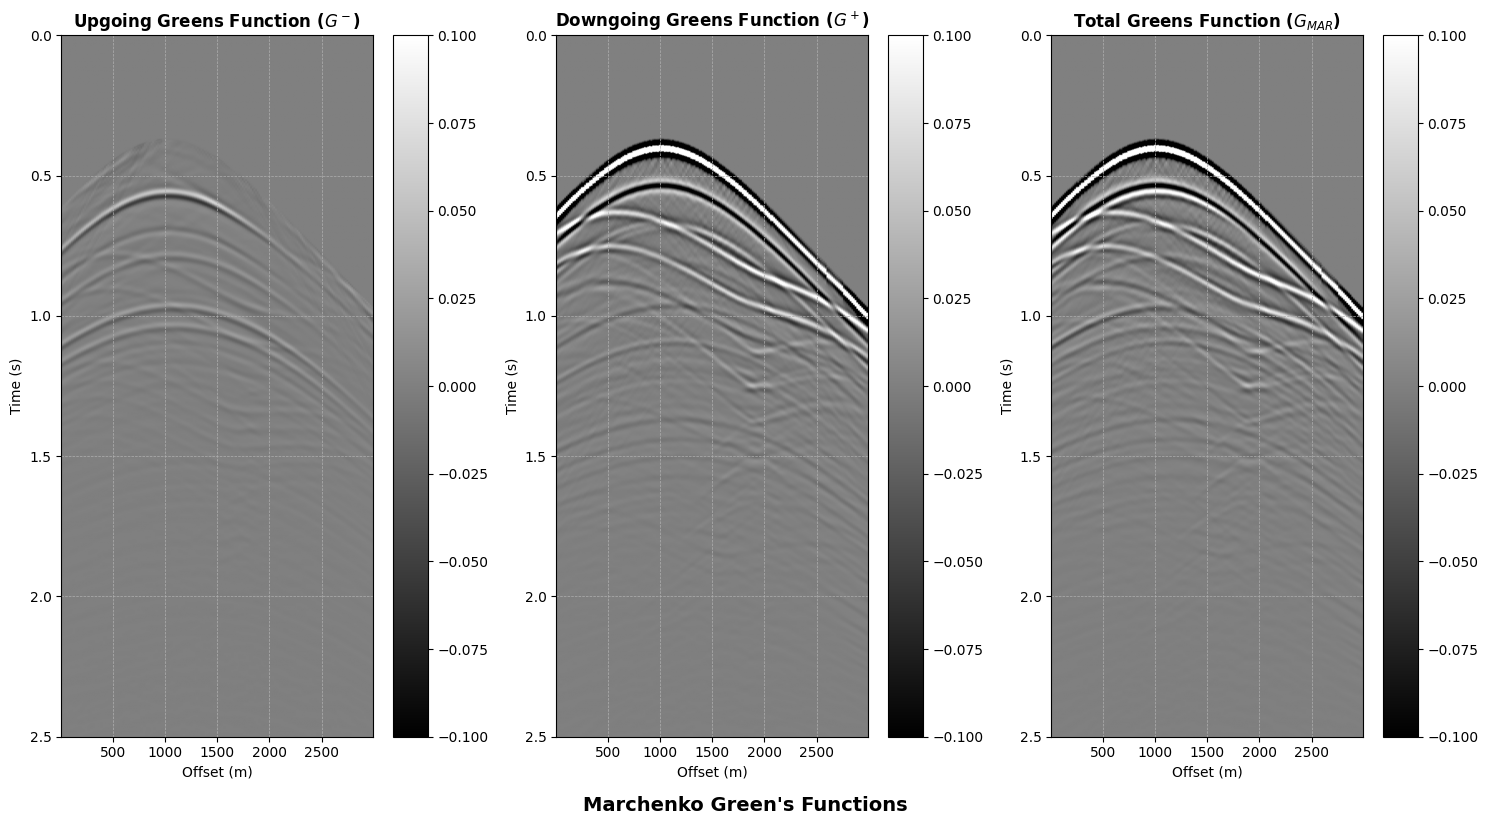

All processes complete and figures saved successfully!


In [6]:
def marchenko_green_function_gpu(direct, filter_array, sg, nitr):
    """
    Iteratively solves the Marchenko equations to retrieve the Green's Functions.

    This function expects CuPy (GPU) arrays. All loops utilize vectorized
    batch matrix multiplications and frequency-domain convolutions to run
    massively parallelized on the NVIDIA T4.

    Parameters:
    -----------
    direct : cupy.ndarray
        Direct arrival matrix (from marchenko_direct).
    filter_array : cupy.ndarray
        Causality filter (from marchenko_direct).
    sg : cupy.ndarray
        Measured surface reflection response (in frequency domain).
    nitr : int
        Number of Marchenko iterations to perform.

    Returns:
    --------
    g_plus, g_minus, g_total : cupy.ndarray
        The separated downgoing, upgoing, and total Green's functions.
    """

    #-------------------------------------------
    # 1) FOCUSING FUNCTIONS - INITIAL ESTIMATES
    #-------------------------------------------
    print("GPU: Initializing focusing functions...")

    # Time-reverse direct arrival and convert to frequency domain (f0_plus)
    f0_plus_freq = cp.fft.fft(cp.flipud(direct), axis=0)

    # Batch matrix multiply the reflectivity (sg) with f0_plus_freq (frequency domain multiplication and sum over receivers)
    # to get the initial upgoing estimate np.newaxis allows broadcasting across the 3D reflectivity matrix
    f0_minus = cp.sum(sg * f0_plus_freq[:, cp.newaxis, :], axis=2)

    # Return to time domain, center the zero-time index, and apply causality mute
    f0_minus_time          = cp.real(cp.fft.ifft(f0_minus, axis=0))     # convert to time domain
    f0_minus_time_shift    = cp.fft.ifftshift(f0_minus_time, axes=0)    # apply ifftshift on time axis
    f0_minus_time_windowed = filter_array * f0_minus_time_shift

    # Store both the time-reversed and standard frequency versions for the loop
    fk_minus_tr   = cp.fft.fft(cp.flipud(f0_minus_time_windowed), axis=0)   # time-reversed and transformed back to frequency domain
    f0_minus_freq = cp.fft.fft(f0_minus_time_windowed, axis=0)              # also get frequency version (non-reversed)

    #------------------------------------------------
    # 2) FOCUSING FUNCTIONS - ITERATIVE CALCULATION
    #------------------------------------------------
    print(f"GPU: Starting iterative calculation ({nitr} iterations)...")
    for itr in range(nitr):

        # Update downgoing intermediate function (mk_plus)
        # Convolve reflectivity with fk_minus_tr (time-reversed f0_minus)
        mk_plus = cp.sum(sg * fk_minus_tr[:, cp.newaxis, :], axis=2)

        # Clean mk_plus with the causality window
        mk_plus_time          = cp.real(cp.fft.ifft(mk_plus, axis=0))
        mk_plus_time_shift    = cp.fft.ifftshift(mk_plus_time, axes=0)
        mk_plus_time_windowed = filter_array * mk_plus_time_shift
        mk_plus_freq          = cp.fft.fft(cp.flipud(mk_plus_time_windowed), axis=0)

        # Update upgoing focusing function (fk_minus)
        # Convolve reflectivity with mk_plus
        fk_minus  = cp.sum(sg * mk_plus_freq[:, cp.newaxis, :], axis=2)

        # Return to time domain and apply ifftshift
        fk_minus_time       = cp.real(cp.fft.ifft(fk_minus, axis=0))
        fk_minus_time_shift = cp.fft.ifftshift(fk_minus_time, axes=0)

        # Add the initial estimate back in and apply the window
        # Retrieve initial f0_minus in time domain
        part1 = cp.real(cp.fft.ifft(f0_minus_freq, axis=0))

        # Window the combined signal
        fk_minus_time_windowed = filter_array * (part1 + fk_minus_time_shift)

        # Prepare arrays for the next iteration
        fk_minus_tr   = cp.fft.fft(cp.flipud(fk_minus_time_windowed), axis=0)
        fk_minus_freq = cp.fft.fft(fk_minus_time_windowed, axis=0)

    # Sum initial and updated downgoing to get final downgoing focusing function
    fk_plus_freq = f0_plus_freq + mk_plus_freq

    #--------------------------------
    # 3) CALCULATE GREEN'S FUNCTIONS
    #--------------------------------
    print("GPU: Calculating final Green's functions...")

    # Calculate Upgoing Green's function (G-)
    # g_minus: upgoing response from fk_plus
    g_minus_freq       = cp.sum(sg * fk_plus_freq[:, cp.newaxis, :], axis=2)
    g_minus_time       = cp.real(cp.fft.ifft(g_minus_freq, axis=0))
    g_minus_time_shift = cp.fft.ifftshift(g_minus_time, axes=0)
    g_minus            = -cp.real(cp.fft.ifft(fk_minus_freq, axis=0)) + g_minus_time_shift

    # Calculate Downgoing Green's function (G+)
    # g_plus: downgoing response from fk_minus_tr (this is same as time reversed f0_minus_freq)
    g_plus_freq        = cp.sum(sg * fk_minus_tr[:, cp.newaxis, :], axis=2)
    g_plus_time        = cp.real(cp.fft.ifft(g_plus_freq, axis=0))
    g_plus_time_shift  = cp.fft.ifftshift(g_plus_time, axes=0)
    g_plus             = cp.flipud(cp.real(cp.fft.ifft(fk_plus_freq, axis=0))) - g_plus_time_shift

    # Combine upgoing and downgoing parts to yield the total true wavefield
    g_total = g_minus + g_plus

    #--------------------
    # 4) POST-PROCESSING
    #--------------------

    # Normalize by the global maximum absolute amplitude
    max_amp = cp.max(cp.abs(g_total))
    g_total = g_total / max_amp
    g_plus  = g_plus  / max_amp
    g_minus = g_minus / max_amp

    # Apply pre-direct arrival surgical mute (inverted causality window) to remove noise
    filter2 = 1 - filter_array
    g_total = g_total * filter2
    g_plus  = g_plus  * filter2
    g_minus = g_minus * filter2

    # Convert focusing functions to time domain and normalize
    f0_plus_time  = np.real(np.fft.ifft(f0_plus_freq, axis=0))
    f0_minus_time = np.real(np.fft.ifft(f0_minus_freq, axis=0))
    fk_plus_time  = np.real(np.fft.ifft(fk_plus_freq, axis=0))
    fk_minus_time = np.real(np.fft.ifft(fk_minus_freq, axis=0))

    fk_plus_max    = np.max(np.abs(fk_plus_time))
    f0_plus_time  /= fk_plus_max
    f0_minus_time /= fk_plus_max
    fk_minus_time /= fk_plus_max
    fk_plus_time  /= fk_plus_max

    return g_plus, g_minus, g_total

def main():
    #--------------------------------
    # 1) USER INPUT - SETUP VARIABLES
    #--------------------------------
    # MARCHENKO DEPENDANT PARAMETERS
    nitr    = 5                    # Number of Marchenko iterations
    tp      = 0.2                  # Marchenko edge-taper fraction
    scaling = 1                    # Scaling factor for reflectivity
    dxm     = 8                    # Grid spacing for the eikonal solution in meters
    x       = 1000                 # X-coordinate of the target subsurface image point
    z       = 800                  # Z-coordinate of the target subsurface image point

    # SURVEY DEPENDANT PARAMETERS
    dt      = 0.002                # Time sampling interval (seconds)
    dx      = 16                   # Receiver spacing (meters)
    o_min   = 4                    # Initial receiver offset (meters)
    freq    = 20                   # Peak frequency of Ricker wavelet in Hz

    plt_flag = 'y'                 # 'y' to generate and save plots

    # Setup directories
    # base_dir = os.path.join(os.getcwd(), 'Marchenko')
    base_dir = '/content/drive/MyDrive/Marchenko'

    mat_dir  = os.path.join(base_dir, 'DATA', 'MAT')
    out_dir  = os.path.join(os.getcwd(), 'Marchenko_Outputs')
    os.makedirs(out_dir, exist_ok=True)

    #--------------
    # 2) LOAD DATA
    #--------------
    print("Loading data...")
    try:
        data_dict = {
            key: loadmat(os.path.join(mat_dir, fname))[key]
            for key, fname in zip(['sg', 'eik', 'wav'], [
                'ICCR_marchenko_R.mat',
                'ICCR_marchenko_eik.mat',
                'ICCR_marchenko_wav.mat'
            ])
        }
        # Keep initial loading on CPU as NumPy floats
        sg_cpu  = np.asarray(data_dict['sg'], dtype=np.float32)
        eik_cpu = np.asarray(data_dict['eik'], dtype=np.float32)
        wav_cpu = np.asarray(data_dict['wav'], dtype=np.float32)

    except Exception as e:
        print(f"File load error: {e}")
        return

    #------------------------------------
    # 3) AUTOMATICALLY DEFINED VARIABLES
    #------------------------------------
    ns    = sg_cpu.shape[1]                      # Number of receivers
    ro    = np.arange(o_min, o_min + ns*dx, dx)  # Receiver offset vector
    ts    = sg_cpu.shape[0]                      # Number of time samples
    max_t = (ts//2) * dt                         # Maximum recording time

    # Apply spatial taper (Tukey window) on CPU to smooth boundary artifacts
    tap = tukey(ns, tp).astype(np.float32)
    sg_cpu *= tap[np.newaxis, :]

    # You may aslo define your own taper if you want.
    # tap = np.zeros(ns)
    # n_tap = int(tp * ns)
    # if n_tap > 0:
    #     tap[:n_tap]  = 0.5 - 0.5 * np.cos(np.pi * np.arange(1, n_tap + 1) / (n_tap))
    #     tap[-n_tap:] = 0.5 - 0.5 * np.cos(np.pi * np.arange(n_tap, 0, -1) / (n_tap))
    # sg_cpu *= tap  # Apply taper

    #------------------------------------------------
    # 4) EXTRACT TRAVEL TIMES & DIRECT ARRIVAL (CPU)
    #------------------------------------------------
    ix = int(round(x / dxm))
    iz = int(round(z / dxm))

    # Isolate the exact travel times corresponding to our target point
    tt_cpu = eik_cpu[iz, ix, :].flatten()

    # Calculate direct arrival and mute window (filter) using fast CPU routines
    direct_cpu, filter_cpu = marchenko_direct(tt_cpu, wav_cpu, ns, ts, dt, freq)

    #----------------------------
    # 5) MARCHENKO IMAGING (GPU)
    #----------------------------
    print("Transferring arrays to GPU...")
    # Transfer strictly as float32/complex64 to double calculation speed and save VRAM
    sg_gpu     = cp.asarray(sg_cpu, dtype=cp.float32)
    direct_gpu = cp.asarray(direct_cpu, dtype=cp.float32)
    filter_gpu = cp.asarray(filter_cpu, dtype=cp.float32)

    # Scale reflectivity and transform to frequency domain entirely on the GPU
    sg_fft_gpu = cp.fft.fft(sg_gpu * (-2 * dt * dx * scaling), axis=0)

    # Launch iterative calculations to estimate decomposed Green's functions
    g_plus_gpu, g_minus_gpu, g_total_gpu = marchenko_green_function_gpu(
        direct_gpu, filter_gpu, sg_fft_gpu, nitr )

    #-----------------------------------
    # 6) TRANSFER TO CPU & SAVE FIGURES
    #-----------------------------------
    if plt_flag.lower() == 'y':
        print("Transferring results to CPU for plotting...")

        # .get() is crucial: Matplotlib requires NumPy arrays, not CuPy arrays
        g_minus = g_minus_gpu.get()
        g_plus  = g_plus_gpu.get()
        g_total = g_total_gpu.get()

        time_axis = np.arange(0, max_t, dt)[:ts//2]

        fig, axs = plt.subplots(1, 3, figsize=(15, 8))
        titles = [r'Upgoing Greens Function ($G^-$)',
                  r'Downgoing Greens Function ($G^+$)',
                  r'Total Greens Function ($G_{MAR}$)']

        data_arrays = [g_minus[ts//2:], g_plus[ts//2:], g_total[ts//2:]]

        for i, ax in enumerate(axs):
            im = ax.imshow(data_arrays[i][:len(time_axis)],
                           aspect='auto',
                           extent=[ro.min(), ro.max(), max_t, 0],
                           vmin=-0.1, vmax=0.1,
                           cmap='gray')
            ax.set_xlabel('Offset (m)')
            ax.set_ylabel('Time (s)')
            ax.set_title(titles[i], fontweight='bold')
            ax.set_ylim(max_t-0.5, 0)
            ax.grid(True, linestyle='--', linewidth=0.5)  # Dashed, thin gridlines
            fig.colorbar(im, ax=ax)

        fig.text(0.5, -0.02, 'Marchenko Green\'s Functions', ha='center', fontsize=14, fontweight='bold')
        plt.subplots_adjust(bottom=0.15)  # Add space at bottom for title

        save_path = os.path.join(out_dir, 'marchenko.png')
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Saved: {save_path}")

        plt.tight_layout()
        plt.show()

        print("All processes complete and figures saved successfully!")

if __name__ == "__main__":
    main()


### Key Operations in the Code
1. **Frequency Domain Operations**:
   - Convolutions become multiplications in frequency domain
   - Time reversal becomes complex conjugation
   - FFT/IFFT used for domain conversion

2. **Window Functions**:
   - $\Theta(t)$ is a temporal filter. It act as a `causal time gate` that preserves only physically meaningful arrivals
   - Tukey window tapers source contributions

3. **Iterative Scheme**:
   - Alternates between calculating downgoing (`mk_plus`) and upgoing (`fk_minus`) components
   - Each iteration refines the estimate

4. **Green's Function Construction**:
   - Combines focusing functions with reflectivity
   - Includes both primaries and multiples

### Python Implementation Notes
1. **Array Dimensions**:
   - Time dimension: axis=0
   - Receiver dimension: axis=1
   - Source dimension: axis=2

2. **Critical Operations**:
   ```python
   # Time reversal
   time_reversed = np.flipud(data)
   
   # Frequency domain conversion
   freq_domain = np.fft.fft(data, axis=0)
   
   # Convolution via multiplication
   convolution = np.sum(
       freq_domain_src[:, :, np.newaxis] *
       reflectivity[:, :, :, np.newaxis],
       axis=1
   )
   
   # Windowing
   windowed_data = theta_window * np.fft.ifftshift(
       np.real(np.fft.ifft(freq_data, axis=0)),
       axes=0
   )
   ```

3. **Performance Considerations**:
   - Precompute FFTs of large arrays
   - Use broadcasting instead of loops where possible
   - Optimize memory usage for 3D wavefields

### Single-Sided Reflection Measurements in Seismic Imaging

**Single-sided reflection measurements** refer to seismic data acquisition where receivers are placed on **only one side** of the target area (typically at the Earth's surface), recording reflections from subsurface structures without any receivers below the targets. This is the standard configuration for most seismic surveys.

#### Key Characteristics:
1. **Acquisition Geometry**:
   - Sources and receivers are deployed **exclusively at the surface**
   - No sensors below the target zone
   - Measures only **upgoing waves** (reflections from subsurface)

2. **Mathematical Representation**:
   $$
   \text{Recorded Data: } R(t, \mathbf{x}_r, \mathbf{x}_s) \quad \text{where } \mathbf{x}_s, \mathbf{x}_r \in \text{Surface}
   $$

3. **Wavefield Components**:
   - Contains both **primaries** (direct reflections) and **multiples** (reverberations)
   - Loses information about **downgoing waves** below the surface
   - Contains **overlapping events** from different interfaces

#### Why It's Problematic for Conventional Imaging:
| **Challenge** | **Consequence** |
|---------------|-----------------|
| **Missing transmission data** | Cannot directly image below complex structures |
| **Multiples contamination** | Ghost images and false structures |
| **Limited illumination** | Poor resolution of steeply dipping features |
| **No subsurface wave separation** | Cannot isolate upgoing/downgoing waves |

#### How Marchenko Solves This:
The Marchenko method **mathematically redatums** the single-sided measurements to create **virtual receivers** inside the subsurface:

$$
\begin{align*}
& \text{Input: } R(\omega, \mathbf{x}_s, \mathbf{x}_r) \\
& \text{Output: } G(\omega, \mathbf{x}_v, \mathbf{x}_f)
\end{align*}
$$

Where:
- $\mathbf{x}_v$ = Virtual receiver location
- $\mathbf{x}_f$ = Focal point

#### Advantages Over Conventional Methods:
1. **Multiples Utilization**:  
   Converts destructive multiples into useful signal

2. **Virtual Redatuming**:  
   Creates virtual receivers below complex overburdens

3. **Wavefield Autofocusing**:  
   Reconstructs full wavefield at target depth

4. **Velocity Model Independence**:  
   Requires only traveltime information (not full velocity model)

```mermaid
graph LR
A[Single-Sided<br>Surface Data] --> B{Marchenko Method}
B --> C[Virtual Downhole<br>Receivers]
B --> D[Multiple Removal]
B --> E[Subsurface<br>Green's Functions]
```

#### Real-World Applications:
- **Seismic Interferometry**: Virtual sources below complex overburden
- **Reservoir Monitoring**: Time-lapse imaging without receivers in wells
- **CO₂ Storage**: Subsurface monitoring using surface arrays
- **Earthquake Seismology**: Virtual receivers in subduction zones

**Key Insight**: The Marchenko method leverages the inherent information in surface-recorded multiples to effectively "see behind" geological structures, overcoming the fundamental limitation of single-sided acquisition.

### Key References

---

1. **Lomas, Angus**, and **Andrew Curtis**. "An introduction to Marchenko methods for imaging." *Geophysics* 84, no. 2 (2019): F35-F45. Download the paper [here](https://pubs.geoscienceworld.org/seg/geophysics/article/84/2/F35/569232/An-introduction-to-Marchenko-methods-for-imagingAn), and the original MATLAB code [here](https://wiki.seg.org/wiki/Software:Marchenko_for_imaging).